### imports & directories

In [1]:
from pathlib import Path

from models.A_exc_B_inh_A import A_exc_B_inh_A
from models.qmlif import QMLIFNeuron
from models.synapse import Synapse
from models.current import sinusoidal_current
from analysis import plot

ROOT = Path.cwd().parent
FIG_DIR = ROOT / "fig/neurons_behaviour"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# no-synapse baseline
- excitatory and inhibitory weights are zero $\rightarrow$ no synaptic contribution
- **expected behaviour:** neuron A spikes according to the input current, neuron B does not spike at all

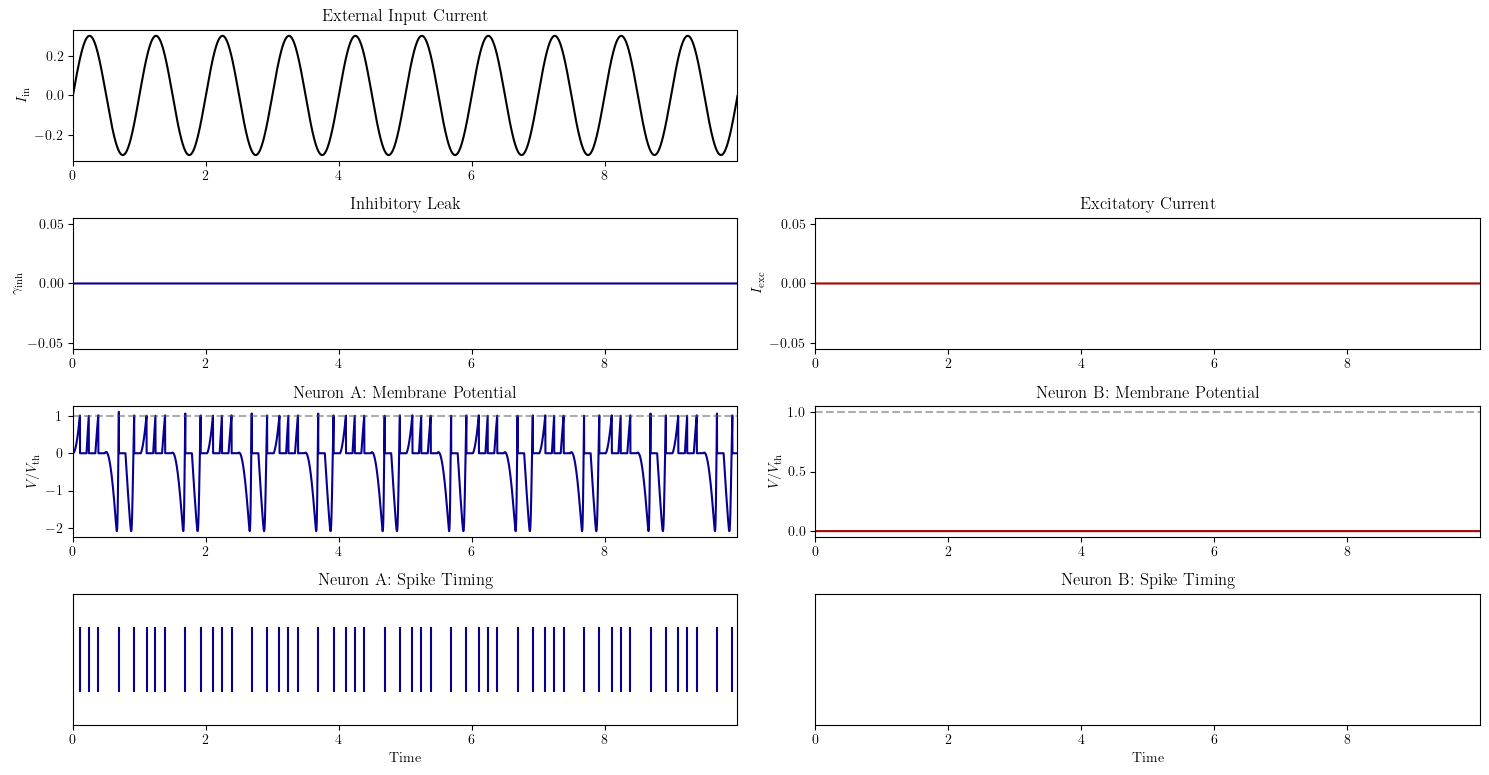

In [2]:
T = 10

NEURON_A_KWARGS = dict(
    name = "neuron A",
    V_th = 0.01
)
neuronA = QMLIFNeuron(**NEURON_A_KWARGS)
neuronB = QMLIFNeuron(name="neuronB")

synapse_exc = Synapse(w=0, tau_syn=0)
synapse_inh = Synapse(w=0, tau_syn=0)

input_current = sinusoidal_current(T=T, T_in=T, I0=0.3, f=1)

network = A_exc_B_inh_A(neuronA, neuronB, synapse_exc, synapse_inh)

simulation_data = network.simulate(T, input_current)

fig = plot.network_response(simulation_data)

# excitatory synapse
- inhibitory weight is zero $\rightarrow$ only excitatory synapse contribution
- **expected behaviour:** neuron A is driven by the input current, neuron B is driven by current from the ecitatory synapse

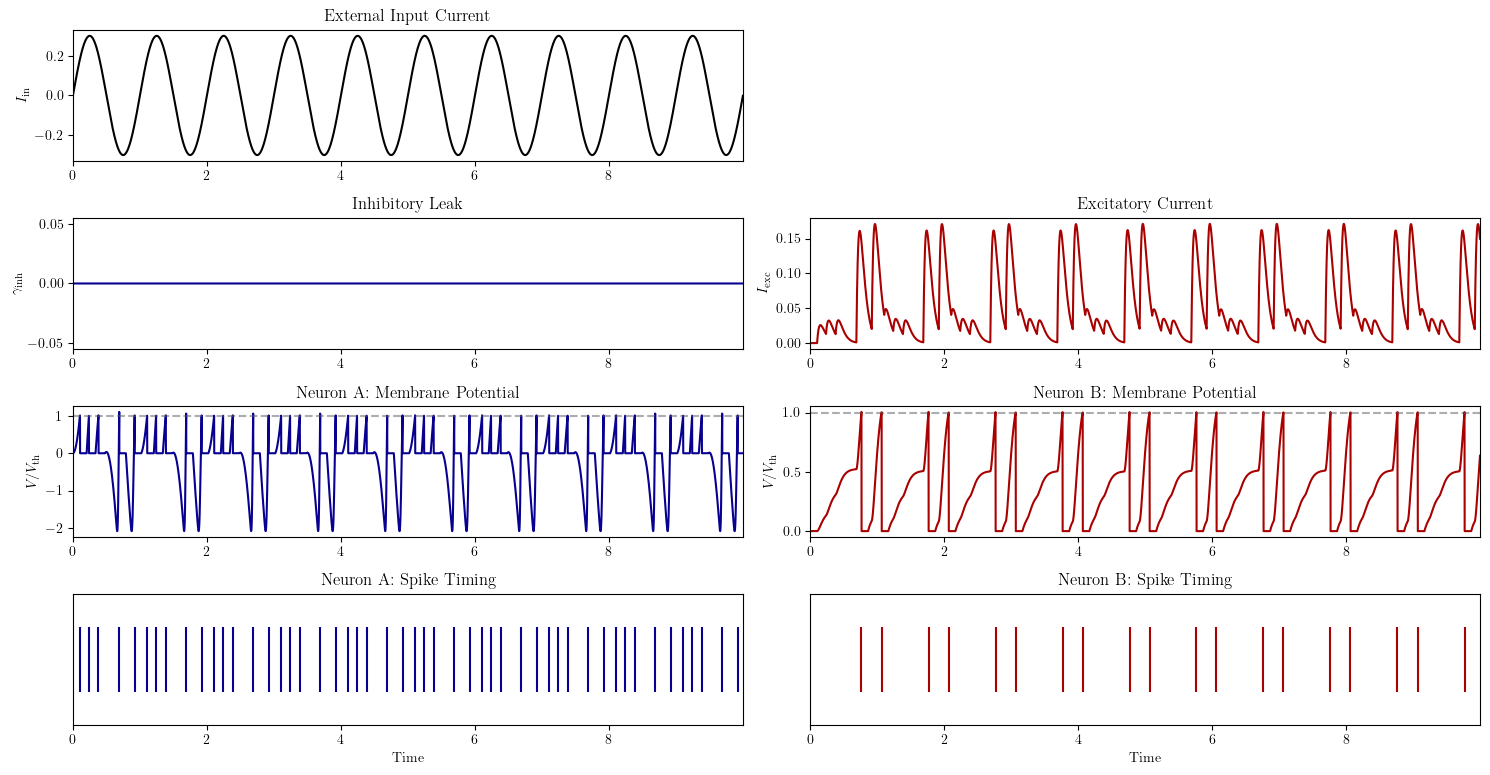

In [3]:
# excitatory synapse: w=0.01, tau=0.05

T = 10

neuronA = QMLIFNeuron(name="neuronA", V_th=0.01)
neuronB = QMLIFNeuron(name="neuronB")

synapse_exc = Synapse(w=0.01, tau_syn=0.05)
synapse_inh = Synapse(w=0, tau_syn=0)

input_current = sinusoidal_current(T=T, T_in=T, I0=0.3, f=1)

network = A_exc_B_inh_A(neuronA, neuronB, synapse_exc, synapse_inh)

simulation_data = network.simulate(T, input_current)

fig = plot.network_response(simulation_data)
fig.savefig(FIG_DIR / "open_loop.pdf", bbox_inches="tight")

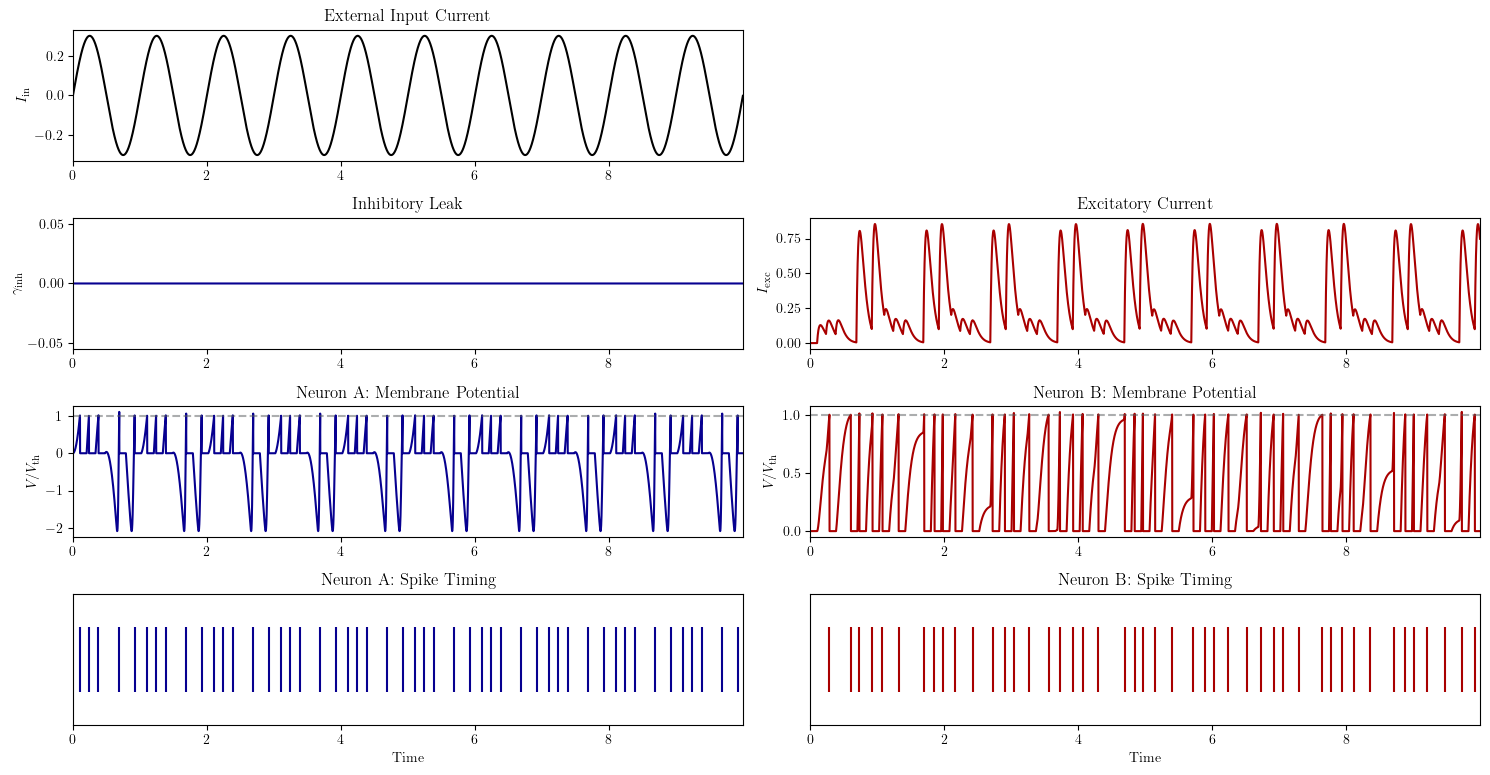

In [4]:
# excitatory synapse: w=0.05, tau=0.05

T = 10

neuronA = QMLIFNeuron(name="neuronA", V_th=0.01)
neuronB = QMLIFNeuron(name="neuronB")

synapse_exc = Synapse(w=0.05, tau_syn=0.05)
synapse_inh = Synapse(w=0, tau_syn=0)

input_current = sinusoidal_current(T=T, T_in=T, I0=0.3, f=1)

network = A_exc_B_inh_A(neuronA, neuronB, synapse_exc, synapse_inh)

simulation_data = network.simulate(T, input_current)

fig = plot.network_response(simulation_data)
fig.savefig(FIG_DIR / "open_loop_w.pdf", bbox_inches="tight")

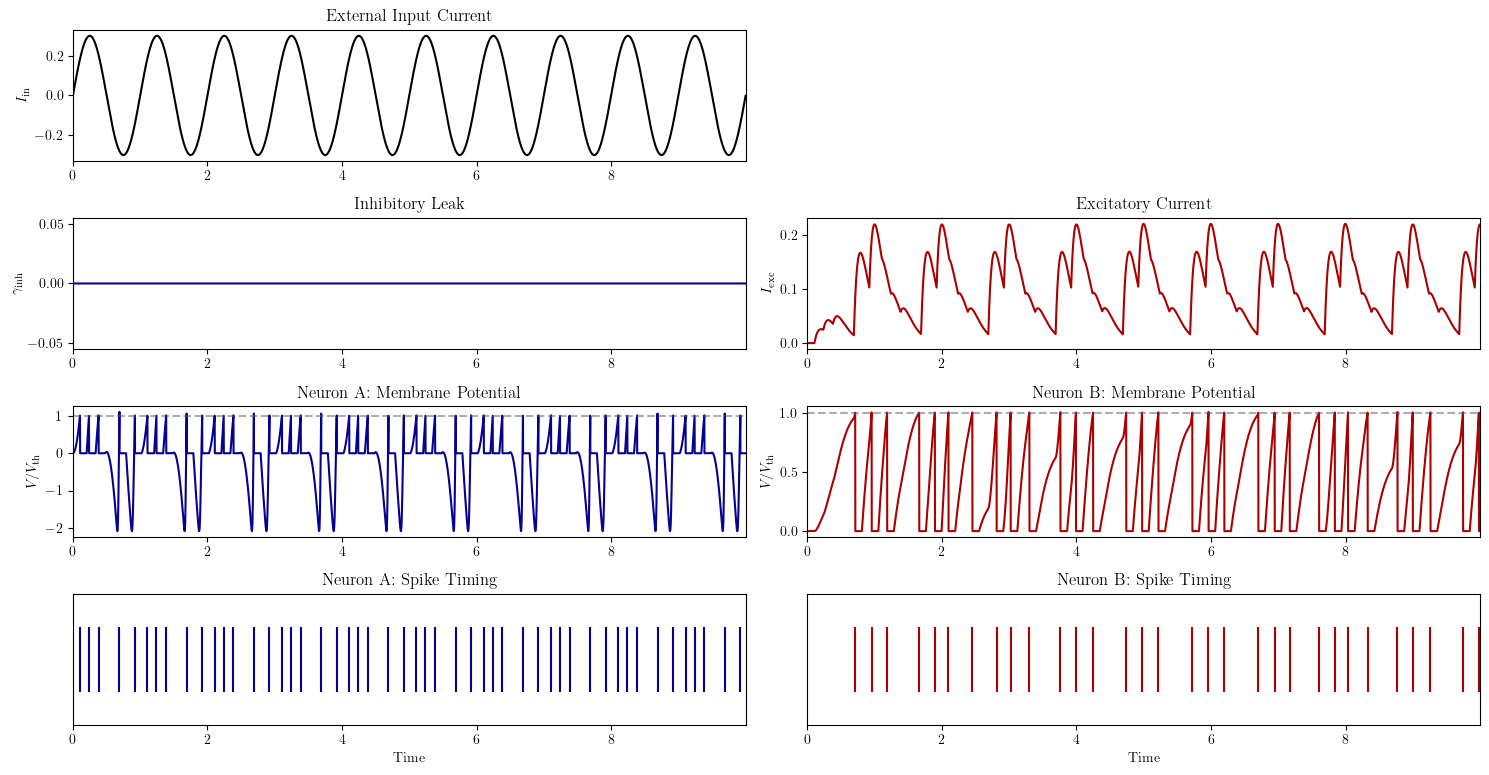

In [5]:
# excitatory synapse: w=0.01, tau=0.1

T = 10

neuronA = QMLIFNeuron(name="neuronA", V_th=0.01)
neuronB = QMLIFNeuron(name="neuronB")

synapse_exc = Synapse(w=0.01, tau_syn=0.1)
synapse_inh = Synapse(w=0, tau_syn=0)

input_current = sinusoidal_current(T=T, T_in=T, I0=0.3, f=1)

network = A_exc_B_inh_A(neuronA, neuronB, synapse_exc, synapse_inh)

simulation_data = network.simulate(T, input_current)

fig = plot.network_response(simulation_data)
fig.savefig(FIG_DIR / "open_loop_tau.pdf", bbox_inches="tight")

# excitatory + inhibitory synapse
- excitatory and inhibitory synapse contribution
- **expected behaviour:** neuron A is driven the input current and inhibitory synapse, neuron B is driven by current from the ecitatory synapse

### $V_\mathrm{thr\ A} = V_\mathrm{thr\ B} = 0.02$

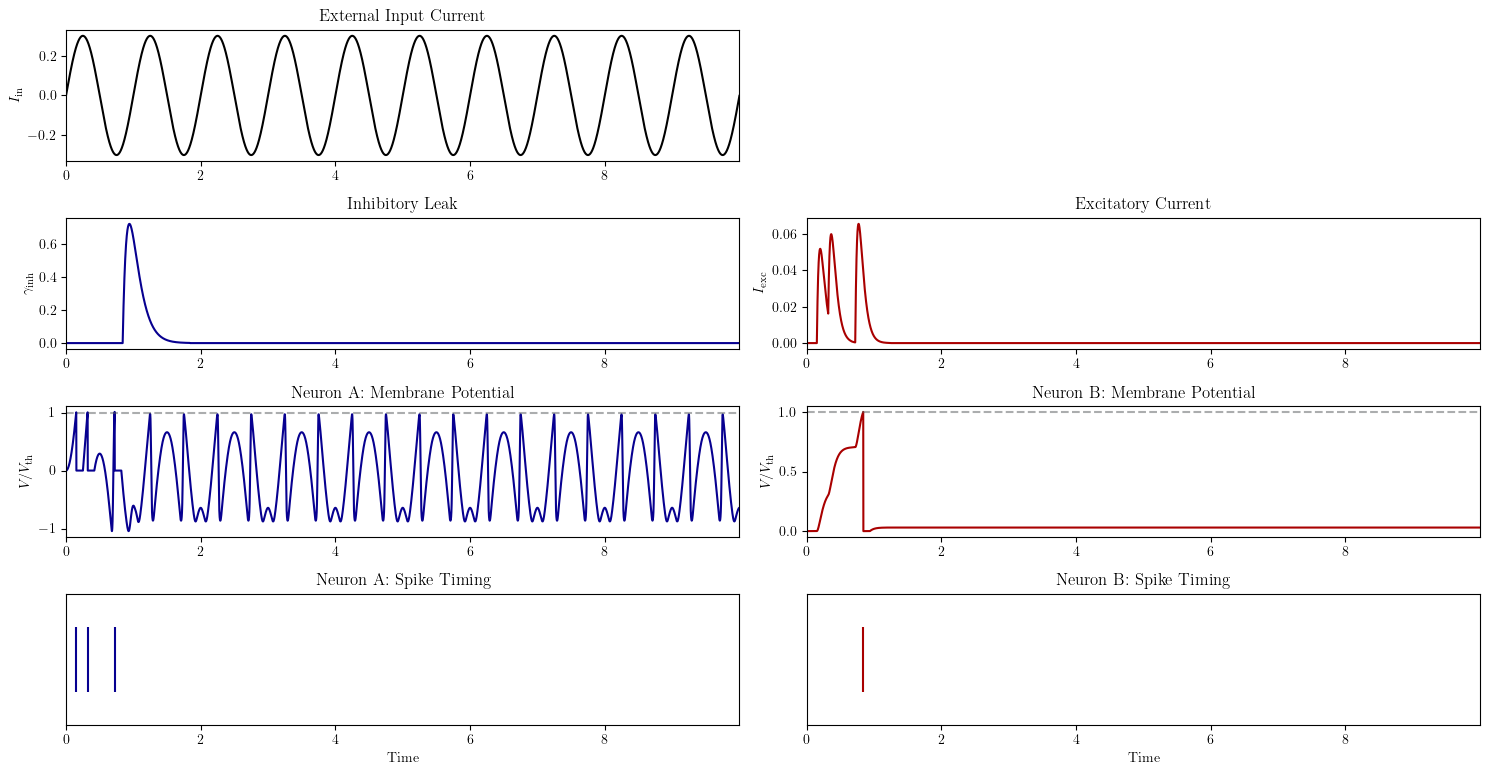

In [6]:
T = 10

neuronA = QMLIFNeuron(name="neuronA")
neuronB = QMLIFNeuron(name="neuronB")

synapse_exc = Synapse(w=0.005, tau_syn=0.05)
synapse_inh = Synapse(w=0.07, tau_syn=0.1)

input_current = sinusoidal_current(T=T, T_in=T, I0=0.3, f=1)

network = A_exc_B_inh_A(neuronA, neuronB, synapse_exc, synapse_inh)

simulation_data = network.simulate(T, input_current)

fig = plot.network_response(simulation_data)

### $V_\mathrm{thr\ A} =0.01 \quad V_\mathrm{thr\ B} = 0.02$

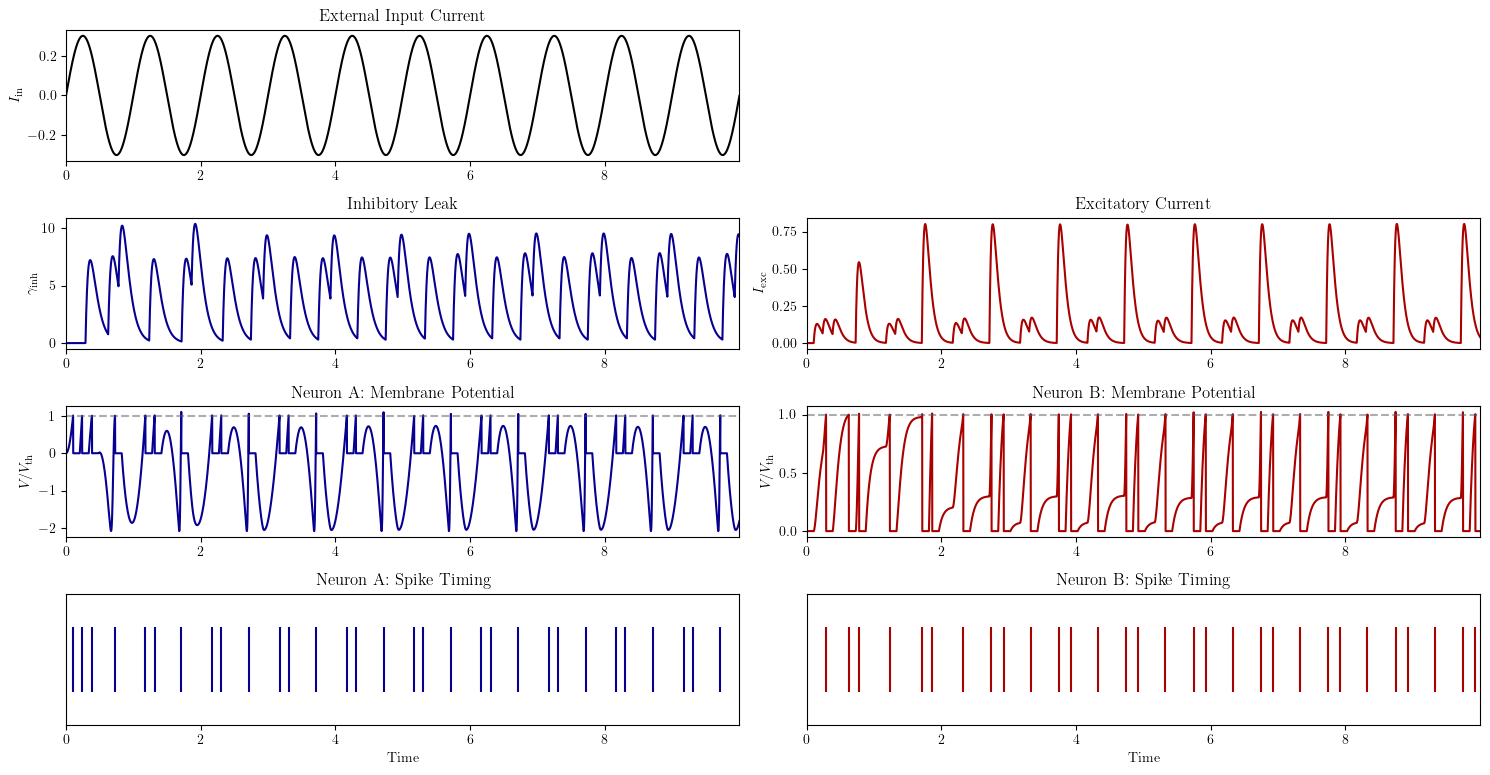

In [7]:
# excitatory synapse: w=0.05, tau=0.05
# inhibitory synapse: w=0.7, tau=0.07

T = 10

neuronA = QMLIFNeuron(name="neuronA", V_th=0.01)
neuronB = QMLIFNeuron(name="neuronB")

synapse_exc = Synapse(w=0.05, tau_syn=0.05)
synapse_inh = Synapse(w=0.7, tau_syn=0.07)

input_current = sinusoidal_current(T=T, T_in=T, I0=0.3, f=1)

network = A_exc_B_inh_A(neuronA, neuronB, synapse_exc, synapse_inh)

simulation_data = network.simulate(T, input_current)

fig = plot.network_response(simulation_data)
fig.savefig(FIG_DIR / "closed_loop.pdf", bbox_inches="tight")


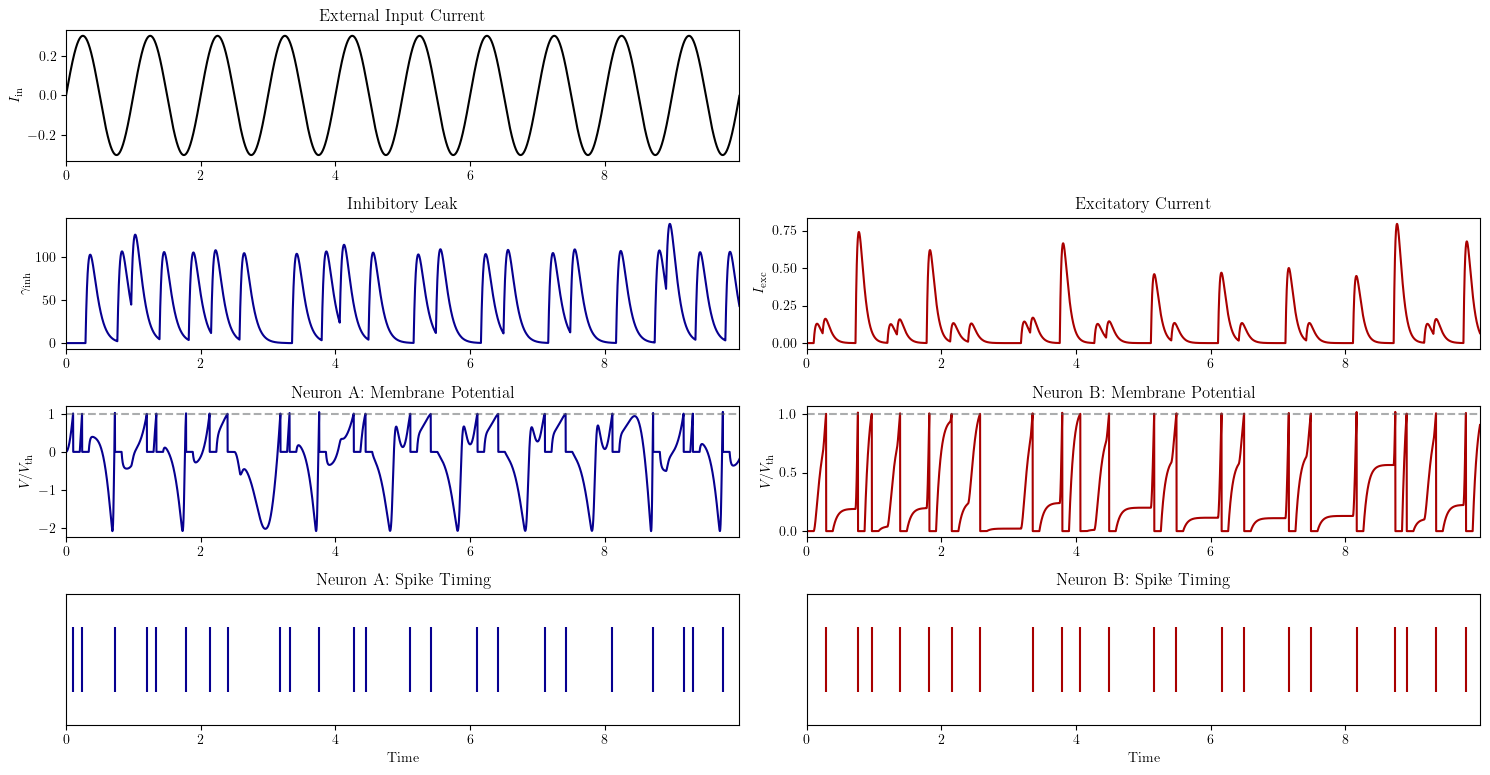

In [8]:
# excitatory synapse: w=0.05, tau=0.05
# inhibitory synapse: w=10, tau=0.07

T = 10

neuronA = QMLIFNeuron(name="neuronA", V_th=0.01)
neuronB = QMLIFNeuron(name="neuronB")

synapse_exc = Synapse(w=0.05, tau_syn=0.05)
synapse_inh = Synapse(w=10, tau_syn=0.07)

input_current = sinusoidal_current(T=T, T_in=T, I0=0.3, f=1)

network = A_exc_B_inh_A(neuronA, neuronB, synapse_exc, synapse_inh)

simulation_data = network.simulate(T, input_current)

fig = plot.network_response(simulation_data)
fig.savefig(FIG_DIR / "closed_loop_w.pdf", bbox_inches="tight")

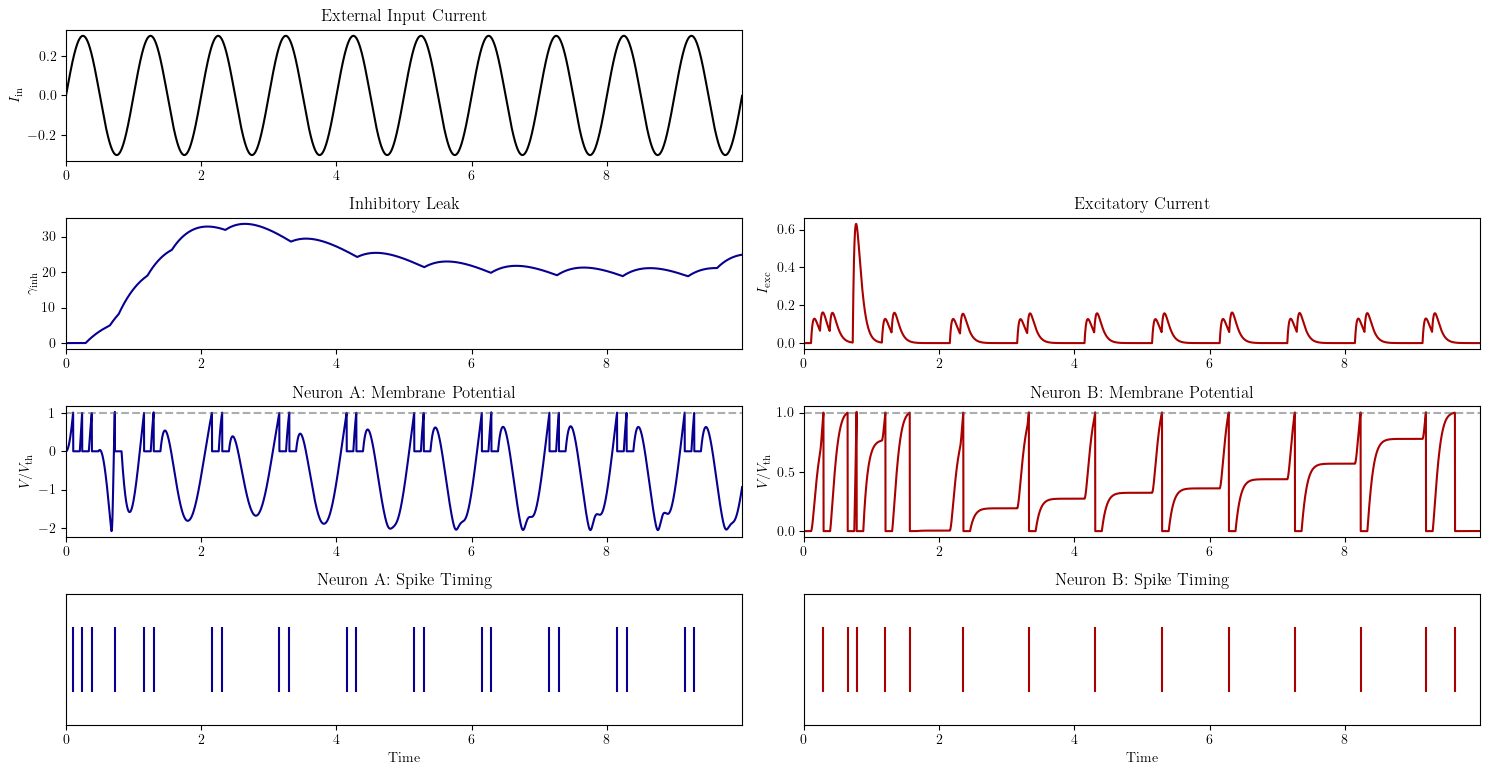

In [9]:
# excitatory synapse: w=0.05, tau=0.05
# inhibitory synapse: w=0.7, tau=1

T = 10

neuronA = QMLIFNeuron(name="neuronA", V_th=0.01)
neuronB = QMLIFNeuron(name="neuronB")

synapse_exc = Synapse(w=0.05, tau_syn=0.05)
synapse_inh = Synapse(w=0.7, tau_syn=1)

input_current = sinusoidal_current(T=T, T_in=T, I0=0.3, f=1)

network = A_exc_B_inh_A(neuronA, neuronB, synapse_exc, synapse_inh)

simulation_data = network.simulate(T, input_current)

fig = plot.network_response(simulation_data)
fig.savefig(FIG_DIR / "closed_loop_tau.pdf", bbox_inches="tight")